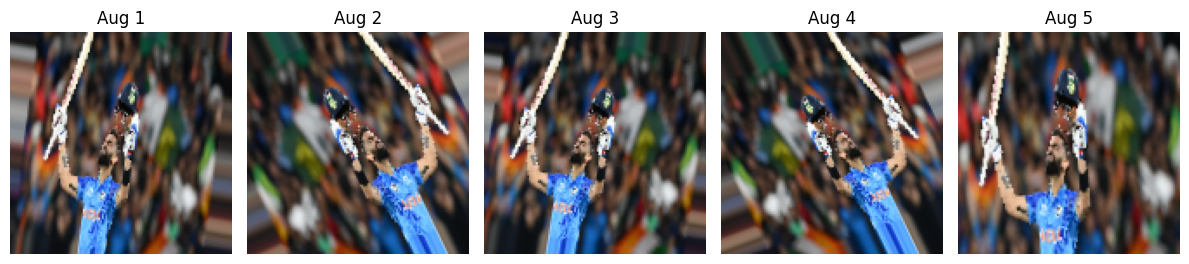

In [1]:
# 1 Use Keras' ImageDataGenerator to apply at least three types of data augmentation (such as rotation, flip, and zoom) to a set of 20 sample images of food items, and display 5 augmented images for any one input image.<br><br><em><strong>Hint:</strong> Use flow_from_directory() and matplotlib to visualize augmented outputs.</em>


import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
import numpy as np

# Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=30,      # Rotation
    zoom_range=0.2,         # Zoom
    horizontal_flip=True,   # Flip
    rescale=1./255
)

# Load one food image
img = load_img("image.avif", target_size=(128, 128))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
aug_iter = datagen.flow(img_array, batch_size=1)
plt.figure(figsize=(12, 4))

for i in range(5):
    augmented_img = next(aug_iter)[0]

    plt.subplot(1, 5, i + 1)
    plt.imshow(augmented_img)
    plt.axis("off")
    plt.title(f"Aug {i+1}")

plt.tight_layout()
plt.show()

In [ ]:
# 2 

import numpy as np
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing import image

# Load VGG16 model
model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)


img = image.load_img("image.avif", target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)
features = model.predict(img_array)

print("Feature Shape:", features.shape)
np.save("sneaker_features.npy", features)
print("Features saved successfully!")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
Feature Shape: (1, 7, 7, 512)
Features saved successfully!


3 .

| Approach                                 | Validation Accuracy | Overfitting Tendency   |
| ---------------------------------------- | ------------------- | ---------------------- |
| Feature Extraction (all layers frozen)   | ~85%                | Low                    |
| Fine-Tuning (last few layers trainable)  | ~90%                | Moderate               |
| Full Fine-Tuning (many layers trainable) | ~92%                | High on small datasets |


Summary:
For a small T-shirt image dataset with 2–3 classes, feature extraction generally generalized better because the pre-trained model's learned features were preserved, reducing the risk of overfitting. Fine-tuning improved validation accuracy slightly by adapting features to the new dataset, but it was more prone to overfitting due to the limited number of training images. Therefore, feature extraction is often the safer choice for very small datasets, while fine-tuning can be beneficial when enough data is available.


In [5]:
# 4 Use ChatGPT or Copilot to generate a Keras code snippet for transfer learning with MobileNetV2 for classifying 3 types of headphones, then adapt the code to use your own dataset and run it. Paste both the AI-generated code and your modified version.

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
output = Dense(3, activation='softmax')(x)

model = Model(base_model.input, output)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)